In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,plot_confusion_matrix

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/machine-predictive-maintenance-classification/predictive_maintenance.csv


In [2]:
import pandas as pd 
df=pd.read_csv("../input/machine-predictive-maintenance-classification/predictive_maintenance.csv")

In [3]:
tc=df['Target'].value_counts()

#### The distribution of target data is as follows

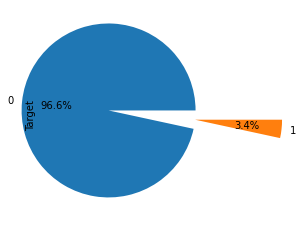

In [4]:
x=df['Target'].value_counts().plot.pie(explode=[0.5, 0.5],autopct='%1.1f%%')

### Since the failure and non failures are very disproportionate lets seperate them and plot individually 

#### Lets create a new feature temperature difference 

In [5]:
df['td']=df['Process temperature [K]']-df['Air temperature [K]']

In [6]:
df["Process_temp_normalized"]=(df["Process temperature [K]"]-min(df['Air temperature [K]']))/(max(df['Process temperature [K]'])-min(df['Air temperature [K]']))
df["Air_temp_normalized"]=(df["Air temperature [K]"]-min(df['Air temperature [K]']))/(max(df['Process temperature [K]'])-min(df['Air temperature [K]']))

In [7]:
df['Temp_diff']=df['Process_temp_normalized']=df['Air_temp_normalized']

In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,td,Process_temp_normalized,Air_temp_normalized,Temp_diff
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,0.151351,0.151351,0.151351
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,0.156757,0.156757,0.156757
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,0.151351,0.151351,0.151351
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,0.156757,0.156757,0.156757
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,0.156757,0.156757,0.156757


In [9]:
df_pass=df[df['Target']==0]
df_pass=df_pass[df_pass['Failure Type']=='No Failure']
df_fail=df[df['Target']==1]
df_fail=df_fail[df_fail['Failure Type']!='No Failure']

df1=df[df['Failure Type']=='Heat Dissipation Failure']
df2=df[df['Failure Type']=='Power Failure']
df3=df[df['Failure Type']=='Overstrain Failure']
df4=df[df['Failure Type']=='Tool Wear Failure']
df5=df[df['Failure Type']=='Random Failures ']

#### The distribution of temperature difference for all non failures

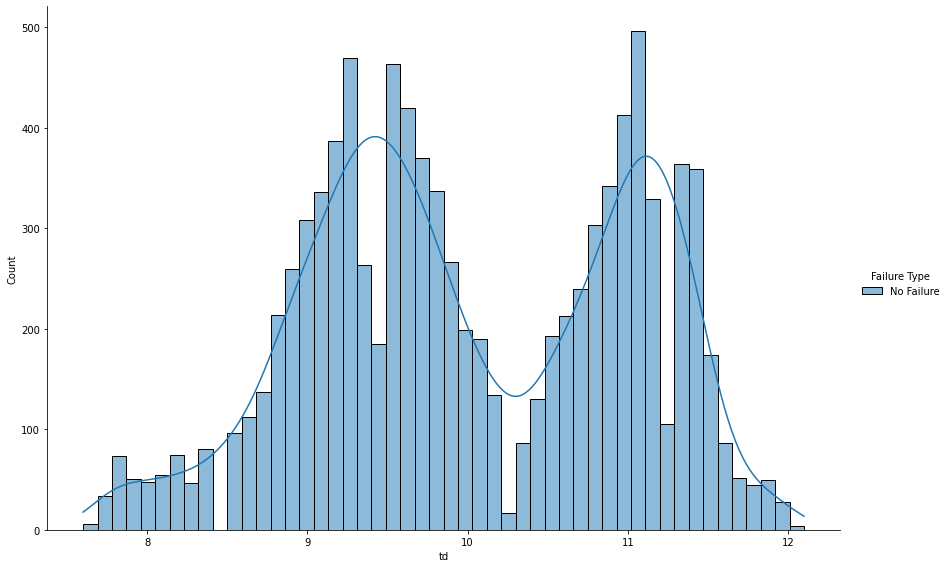

In [10]:
sns.displot(data=df_pass, x="td",hue="Failure Type", kde=True, bins = 50,height = 8, aspect =1.5)

## Distribution of temperature difference and respective failure types when failure occus is as follows

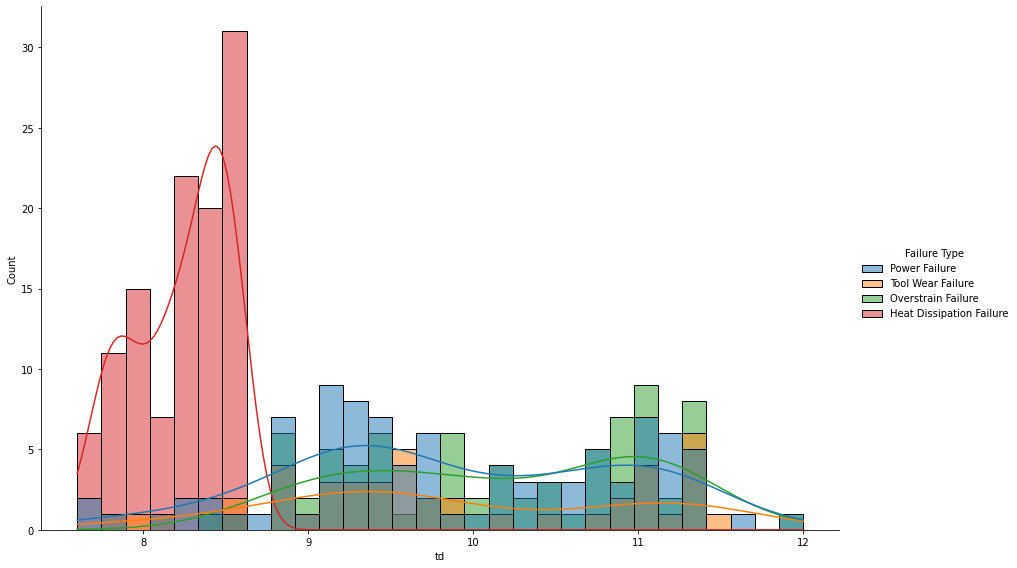

In [11]:
sns.displot(data=df_fail, x="td",hue="Failure Type", kde=True, bins = 30,height = 8, aspect =1.5)

## The distribution of air temperature when failures occur

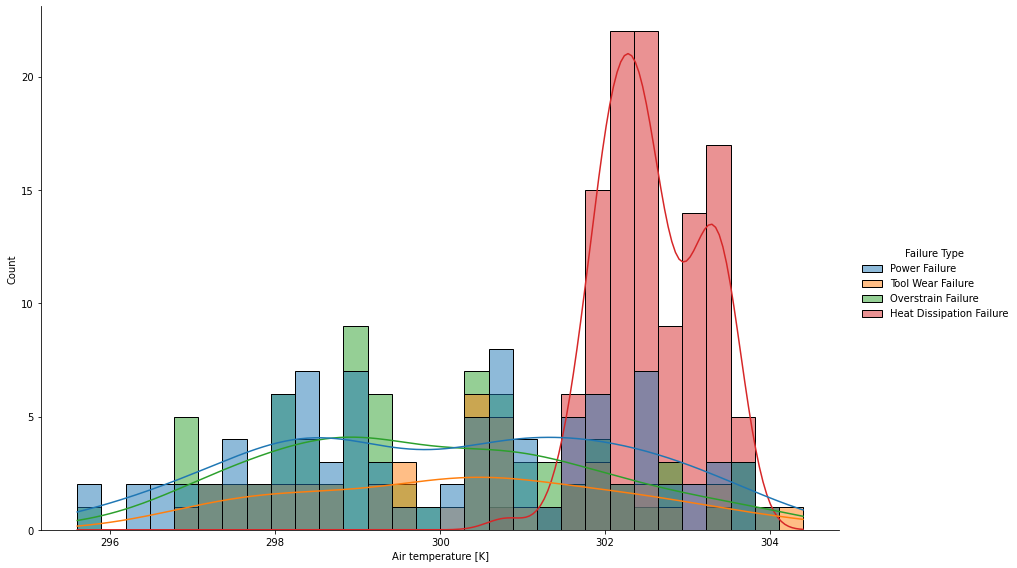

In [12]:
sns.displot(data=df_fail, x="Air temperature [K]",hue="Failure Type", kde=True, bins = 30,height = 8, aspect =1.5)

## The distribution of process temperature when failure occur is shown below 

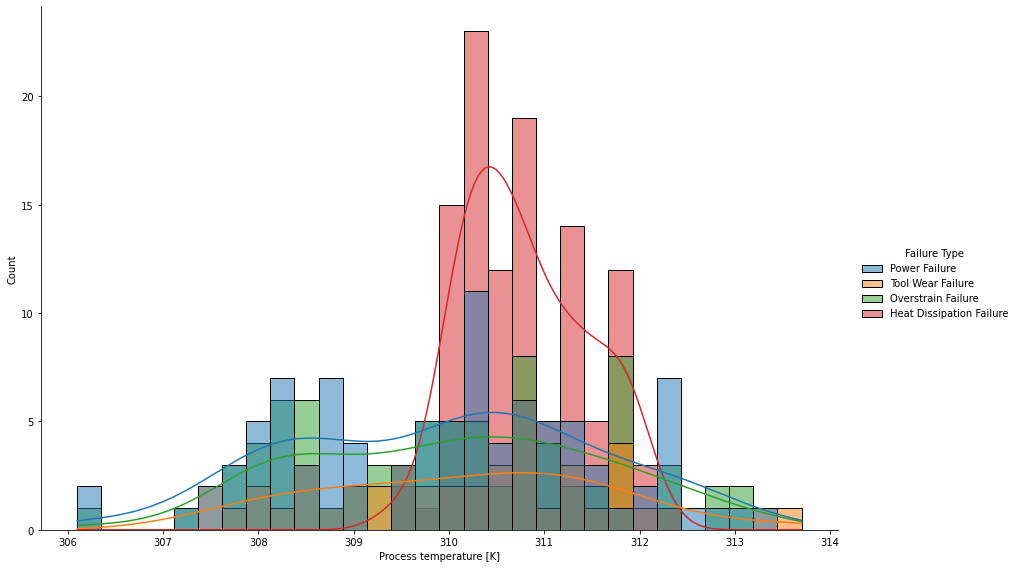

In [13]:
sns.displot(data=df_fail, x="Process temperature [K]",hue="Failure Type", kde=True, bins = 30,height = 8, aspect =1.5)

##### Seening the above three plots it confirms that Heat Dissipation Failures are more dependent on temperature difference than either the air or process temperature

## The pie chart of all types os machines in our data is as follows

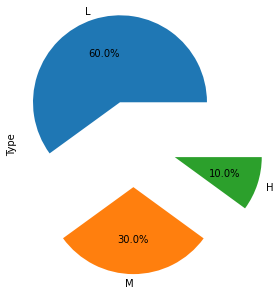

In [14]:
x=df['Type'].value_counts().plot.pie(explode=[0.5, 0.5,0.5],autopct='%1.1f%%')

## Pie chart of total machines that do not fail

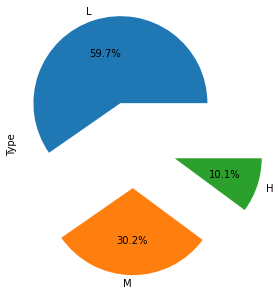

In [15]:
x=df_pass['Type'].value_counts().plot.pie(explode=[0.5, 0.5,0.5],autopct='%1.1f%%')

## Pie chart of machines that failed

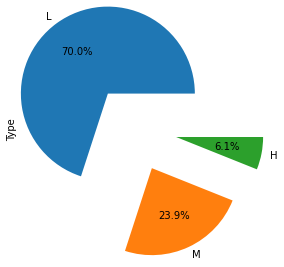

In [16]:
x=df_fail['Type'].value_counts().plot.pie(explode=[0.5, 0.5,0.5],autopct='%1.1f%%')

#### In conclusion machines of type H fail less often

## The distribution of RPM on failed data is shown below

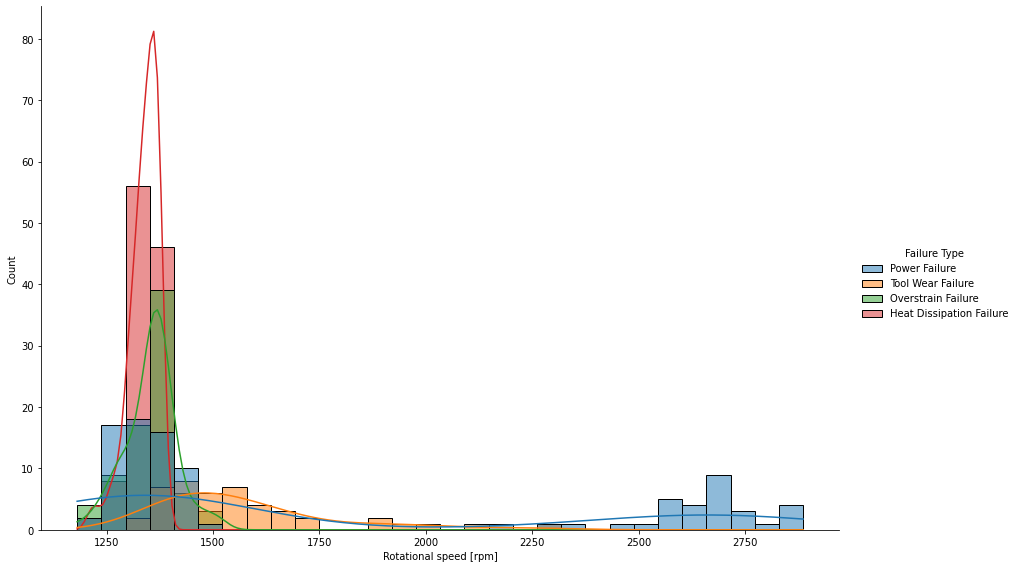

In [17]:
sns.displot(data=df_fail, x="Rotational speed [rpm]",hue="Failure Type", kde=True, bins = 30,height = 8, aspect =1.5)

## The distribution of RPM when failure occue is as follows

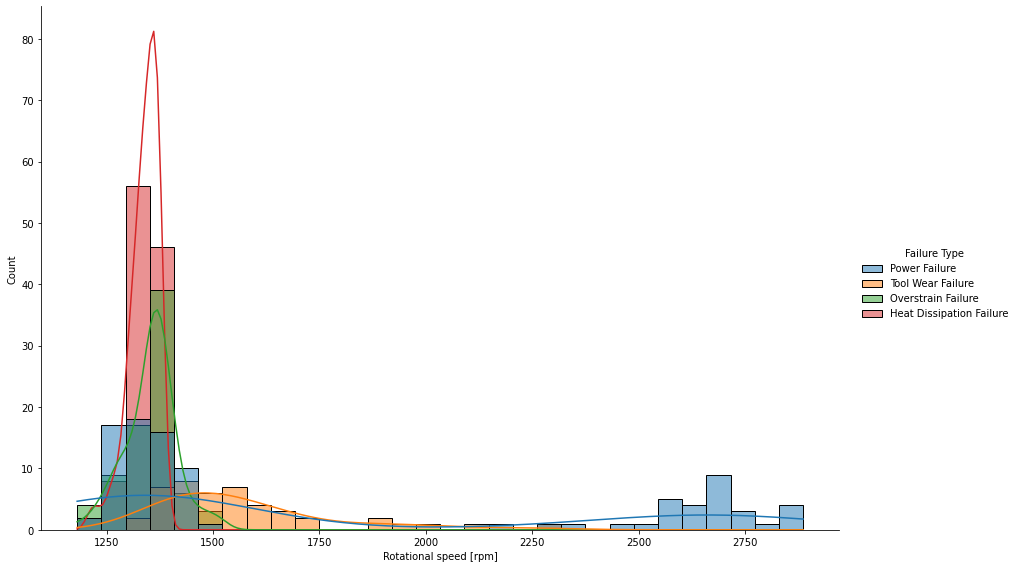

In [18]:
sns.displot(data=df_fail, x="Rotational speed [rpm]",hue="Failure Type", kde=True, bins = 30,height = 8, aspect =1.5)

## Lets see the plot of RPM and torque

<AxesSubplot:xlabel='Rotational speed [rpm]', ylabel='Torque [Nm]'>

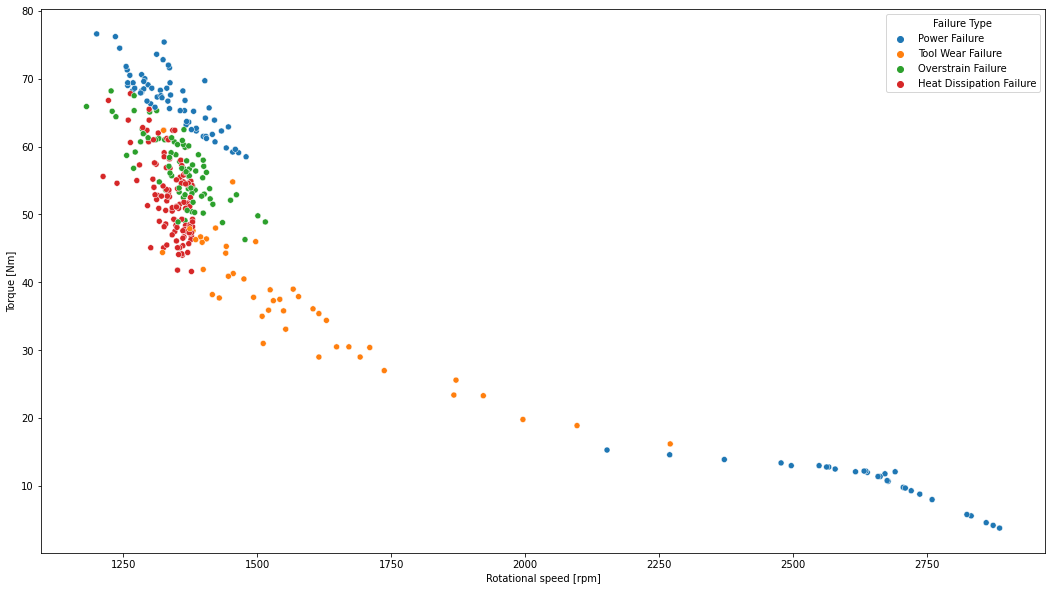

In [19]:

plt.figure(figsize=(18,10))
sns.scatterplot(data=df_fail,x="Rotational speed [rpm]",y='Torque [Nm]',hue="Failure Type")

In [20]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type', 'td',
       'Process_temp_normalized', 'Air_temp_normalized', 'Temp_diff'],
      dtype='object')

## The distribution of tool wear is as follows

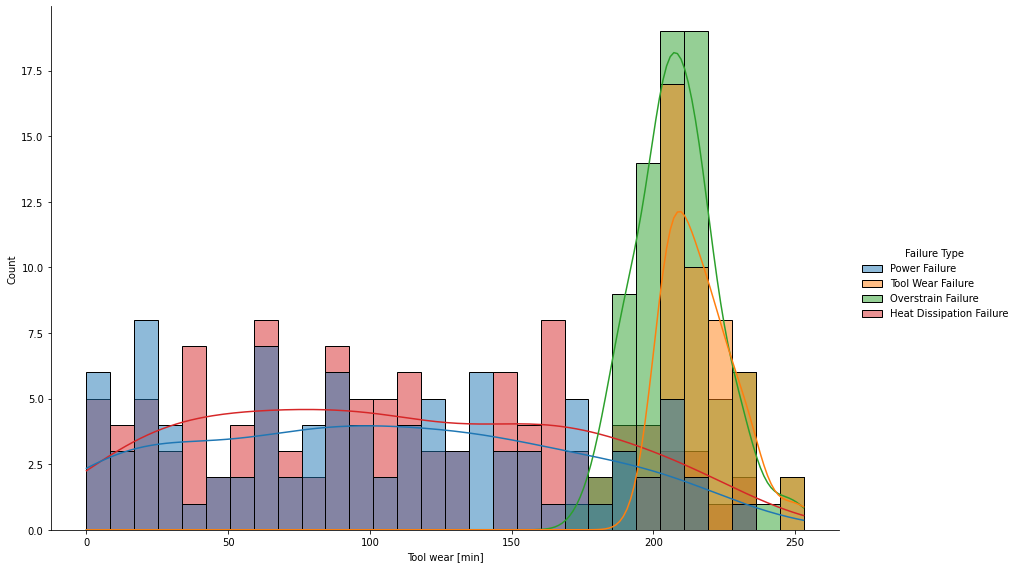

In [21]:
sns.displot(data=df_fail, x="Tool wear [min]",hue="Failure Type", kde=True, bins = 30,height = 8, aspect =1.5)

#### It is clearly evident that failures like Overstrain failure and tool wear failure are very dependent on tool wear 

## The plot of  rpm  wrt tool wear is as follows

<AxesSubplot:xlabel='Tool wear [min]', ylabel='Rotational speed [rpm]'>

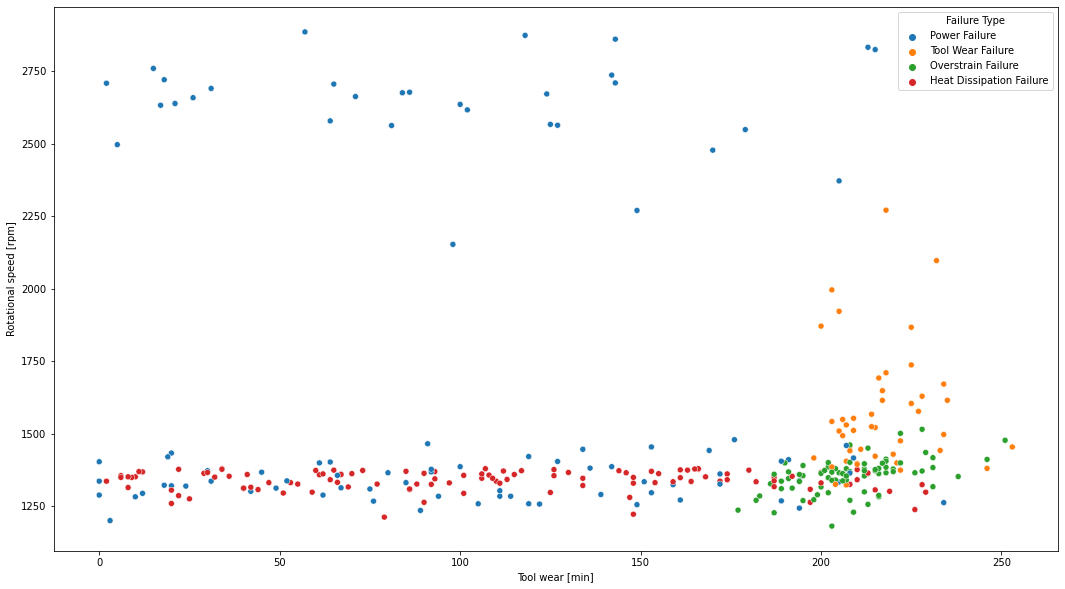

In [22]:
plt.figure(figsize=(18,10))
sns.scatterplot(data=df_fail,x="Tool wear [min]",y='Rotational speed [rpm]',hue="Failure Type")

#### Here is something interesting the heat dessipation failure only occured when the RPM was below 1500 and it seems to be independent of tool wear

## The plot of tool wear and torque is as follows

<AxesSubplot:xlabel='Tool wear [min]', ylabel='Torque [Nm]'>

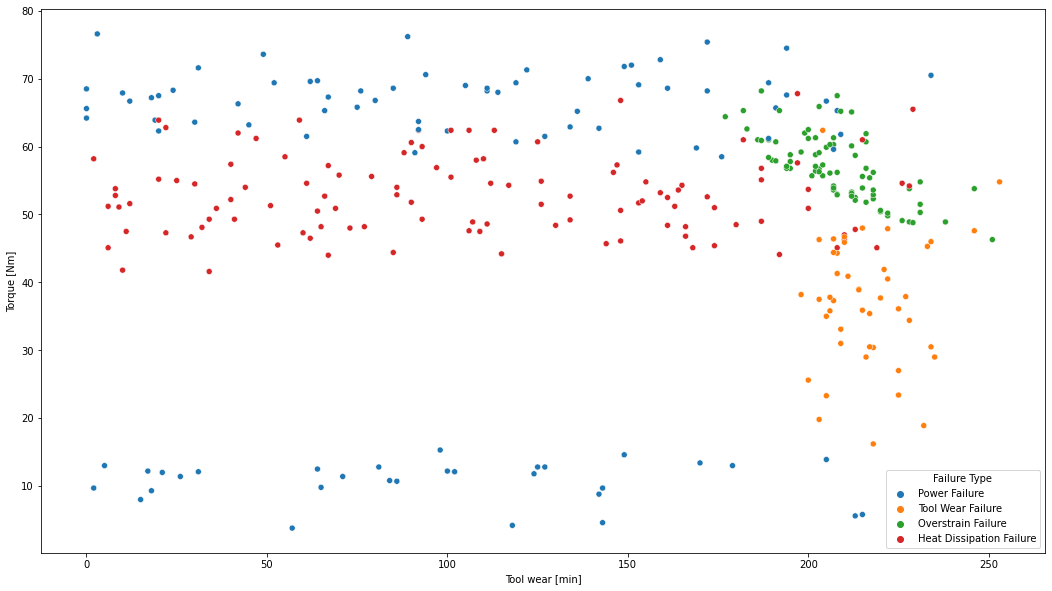

In [23]:
plt.figure(figsize=(18,10))
sns.scatterplot(data=df_fail,x="Tool wear [min]",y='Torque [Nm]',hue="Failure Type")

## The plor of temperature difference and rpm is as follows

<AxesSubplot:xlabel='td', ylabel='Rotational speed [rpm]'>

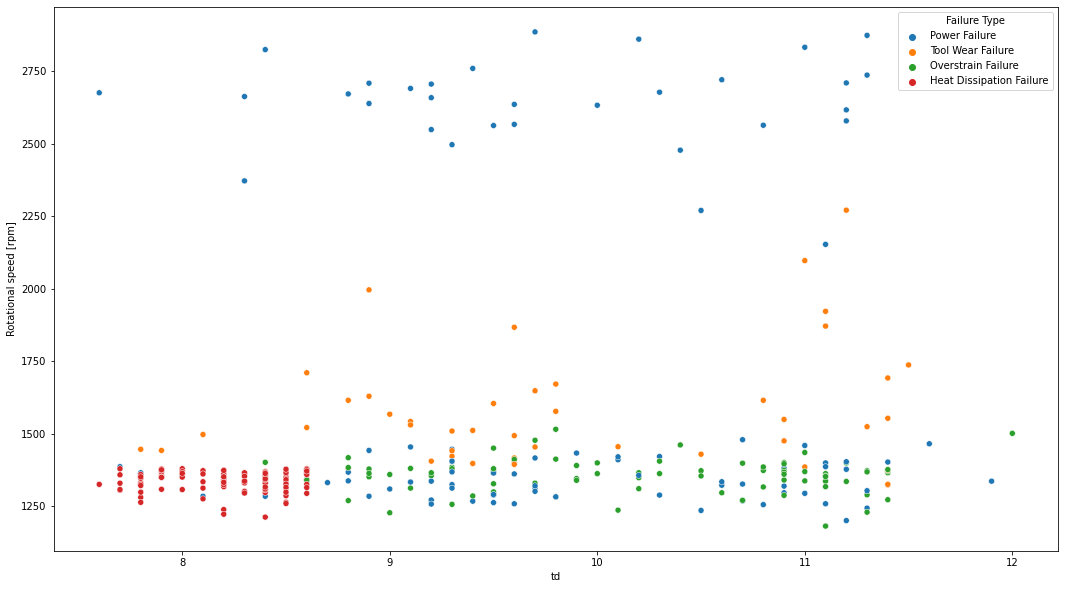

In [24]:
plt.figure(figsize=(18,10))
sns.scatterplot(data=df_fail,x="td",y='Rotational speed [rpm]',hue="Failure Type")

## The plot of torque wrt temperarture difference is as follows

<AxesSubplot:xlabel='td', ylabel='Torque [Nm]'>

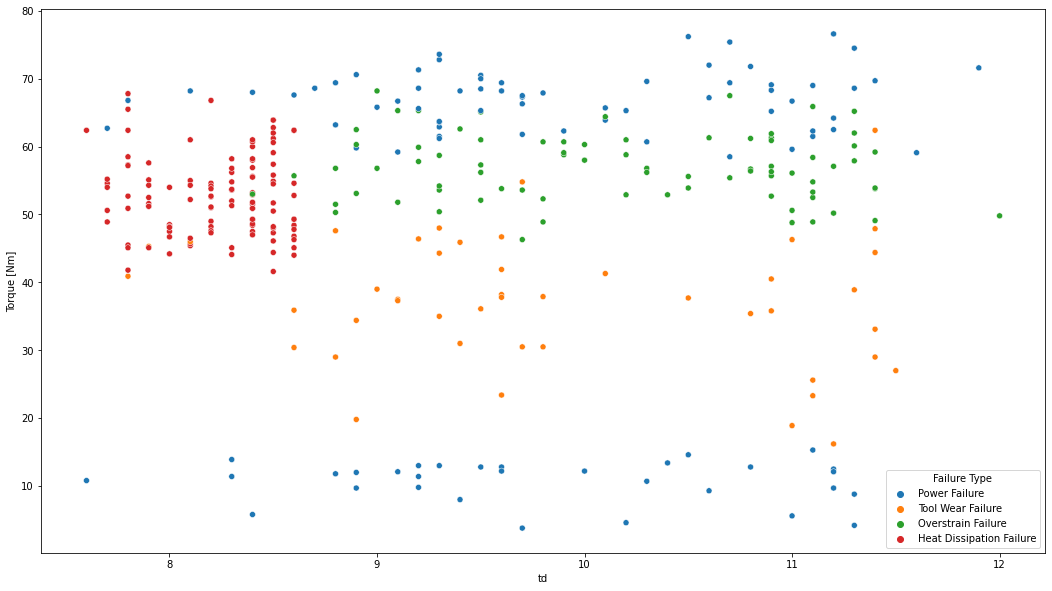

In [25]:
plt.figure(figsize=(18,10))
sns.scatterplot(data=df_fail,x="td",y='Torque [Nm]',hue="Failure Type")

In [26]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type', 'td',
       'Process_temp_normalized', 'Air_temp_normalized', 'Temp_diff'],
      dtype='object')

## Summarizing the results of all the plots above 
#### 1. Heat dessipation failure occurs at lower RPM and higher torque when the temperature difference is less, meaning it occurs more frequently when the machine is starting 
#### 2.Tool wearing failure occurs mostly when the tool wear min is high, it is indipendent of rpm and torque 
#### 3. Over strain failure happnes at higher torque and lower RPM but unlike heat dessipation failure, they are indipendent of temperature difference but they need high tool wear min similar to tool wearing failure
#### 4. Power failures either occur at high torque low rpm or high rpm low torque 

## Moving forward to training I'll be making two svm based classifires 1 for predicting the type of failure this classisier assums that a failure has occured and other one to determine if a failure occured or not

#### Starting with categorizing the type of failure

#### I have used the min-max normalization to normalize all variable i.e rpm , torque, temperature, tool wear 

In [27]:
df_fail['rpm_norm']=(df_fail['Rotational speed [rpm]']-min(df_fail['Rotational speed [rpm]']))/(max(df_fail['Rotational speed [rpm]'])-min(df_fail['Rotational speed [rpm]']))

In [28]:
df_fail['Torque_norm']=(df_fail['Torque [Nm]']-min(df_fail['Torque [Nm]']))/(max(df_fail['Torque [Nm]'])-min(df_fail['Torque [Nm]']))
df_fail['Tool_norm']=(df_fail['Tool wear [min]']-min(df_fail['Tool wear [min]']))/(max(df_fail['Tool wear [min]'])-min(df_fail['Tool wear [min]']))


In [29]:

df_fail=df_fail.drop(columns=['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Product ID','UDI','Temp_diff','td','Target'])

#### Encoding the data

In [30]:
df_fail = pd.get_dummies(data=df_fail, columns=['Type'],drop_first=True)

scaler = LabelEncoder()
df_fail['Failure Type'] = scaler.fit_transform(df_fail['Failure Type'])

#### Splitting train and target

In [31]:
df_fail_targ=df_fail_train=df_fail.iloc[:,0]
df_fail_train=df_fail.iloc[:,1:]

In [32]:
df_fail

,Failure Type,Process_temp_normalized,Air_temp_normalized,rpm_norm,Torque_norm,Tool_norm,Type_L,Type_M
50,2,0.194595,0.194595,0.985337,0.010989,0.565217,1,0
69,2,0.194595,0.194595,0.134311,0.850275,0.754941,1,0
77,3,0.189189,0.189189,0.160704,0.515110,0.822134,1,0
160,1,0.167568,0.167568,0.059238,0.781593,0.853755,1,0
161,1,0.162162,0.162162,0.135484,0.666209,0.861660,1,0
...,...,...,...,...,...,...,...,...
9758,3,0.178378,0.178378,0.639296,0.170330,0.861660,1,0
9764,2,0.172973,0.172973,0.066276,0.864011,0.047431,1,0
9822,1,0.172973,0.172973,0.104985,0.784341,0.739130,1,0
9830,1,0.162162,0.162162,0.091496,0.718407,0.814229,1,0


In [33]:
df_fail_train

,Process_temp_normalized,Air_temp_normalized,rpm_norm,Torque_norm,Tool_norm,Type_L,Type_M
50,0.194595,0.194595,0.985337,0.010989,0.565217,1,0
69,0.194595,0.194595,0.134311,0.850275,0.754941,1,0
77,0.189189,0.189189,0.160704,0.515110,0.822134,1,0
160,0.167568,0.167568,0.059238,0.781593,0.853755,1,0
161,0.162162,0.162162,0.135484,0.666209,0.861660,1,0
...,...,...,...,...,...,...,...
9758,0.178378,0.178378,0.639296,0.170330,0.861660,1,0
9764,0.172973,0.172973,0.066276,0.864011,0.047431,1,0
9822,0.172973,0.172973,0.104985,0.784341,0.739130,1,0
9830,0.162162,0.162162,0.091496,0.718407,0.814229,1,0


In [34]:
df_fail_targ

50      2
69      2
77      3
160     1
161     1
       ..
9758    3
9764    2
9822    1
9830    1
9974    2
Name: Failure Type, Length: 330, dtype: int64

#### Splitting the train and validation 

In [35]:
X_train,X_test,y_train,y_test = train_test_split(df_fail_train,df_fail_targ,test_size=0.2,random_state=21)

In [36]:
X_train

,Process_temp_normalized,Air_temp_normalized,rpm_norm,Torque_norm,Tool_norm,Type_L,Type_M
9018,0.108108,0.108108,0.254545,0.434066,0.857708,1,0
1682,0.140541,0.140541,0.248094,0.443681,0.889328,0,0
4840,0.437838,0.437838,0.068622,0.825549,0.233202,1,0
1789,0.156757,0.156757,0.077419,0.872253,0.264822,1,0
4355,0.362162,0.362162,0.058065,0.734890,0.581028,0,0
...,...,...,...,...,...,...,...
4157,0.362162,0.362162,0.048094,0.780220,0.355731,1,0
1808,0.151351,0.151351,0.812903,0.123626,0.494071,1,0
6497,0.297297,0.297297,0.076833,0.844780,0.758893,1,0
9084,0.102703,0.102703,0.085044,0.983516,0.679842,1,0


#### Training and predicting the results

In [37]:

svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

train_acc = round(svc.score(X_train, y_train) * 100, 1)
val_acc = round(accuracy_score(y_pred, y_test) * 100, 2)

print("Training Accuracy    :",train_acc ,"%")
print("Model Accuracy Score :",val_acc ,"%")


Training Accuracy    : 82.6 %
Model Accuracy Score : 83.33 %


/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


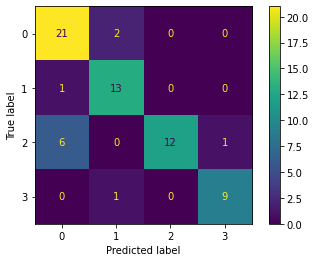

In [38]:
plot_confusion_matrix(svc, X_test, y_test)

## Moving forward to failure or not failure classifier

#### Starting with the normalization

In [39]:
df['rpm_norm']=(df['Rotational speed [rpm]']-min(df['Rotational speed [rpm]']))/(max(df['Rotational speed [rpm]'])-min(df['Rotational speed [rpm]']))
df['Torque_norm']=(df['Torque [Nm]']-min(df['Torque [Nm]']))/(max(df['Torque [Nm]'])-min(df['Torque [Nm]']))
df['Tool_norm']=(df['Tool wear [min]']-min(df['Tool wear [min]']))/(max(df['Tool wear [min]'])-min(df['Tool wear [min]']))


#### Dropping the unnecessary

In [40]:

df2=df.drop(columns=['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Product ID','UDI','Temp_diff','td','Failure Type'])

In [41]:
df2

,Type,Target,Process_temp_normalized,Air_temp_normalized,rpm_norm,Torque_norm,Tool_norm
0,M,0,0.151351,0.151351,0.222934,0.535714,0.000000
1,L,0,0.156757,0.156757,0.139697,0.583791,0.011858
2,L,0,0.151351,0.151351,0.192084,0.626374,0.019763
3,L,0,0.156757,0.156757,0.154249,0.490385,0.027668
4,L,0,0.156757,0.156757,0.139697,0.497253,0.035573
...,...,...,...,...,...,...,...
9995,M,0,0.189189,0.189189,0.253783,0.353022,0.055336
9996,H,0,0.194595,0.194595,0.270081,0.384615,0.067194
9997,M,0,0.200000,0.200000,0.277648,0.406593,0.086957
9998,H,0,0.200000,0.200000,0.139697,0.614011,0.098814


#### Encoding the type feature

In [42]:
df2 = pd.get_dummies(data=df2, columns=['Type'],drop_first=True)


In [43]:
df2

,Target,Process_temp_normalized,Air_temp_normalized,rpm_norm,Torque_norm,Tool_norm,Type_L,Type_M
0,0,0.151351,0.151351,0.222934,0.535714,0.000000,0,1
1,0,0.156757,0.156757,0.139697,0.583791,0.011858,1,0
2,0,0.151351,0.151351,0.192084,0.626374,0.019763,1,0
3,0,0.156757,0.156757,0.154249,0.490385,0.027668,1,0
4,0,0.156757,0.156757,0.139697,0.497253,0.035573,1,0
...,...,...,...,...,...,...,...,...
9995,0,0.189189,0.189189,0.253783,0.353022,0.055336,0,1
9996,0,0.194595,0.194595,0.270081,0.384615,0.067194,0,0
9997,0,0.200000,0.200000,0.277648,0.406593,0.086957,0,1
9998,0,0.200000,0.200000,0.139697,0.614011,0.098814,0,0


In [44]:
train=df2.iloc[:,1:]

In [45]:
tar=df2.iloc[:,0]

In [46]:
df2

,Target,Process_temp_normalized,Air_temp_normalized,rpm_norm,Torque_norm,Tool_norm,Type_L,Type_M
0,0,0.151351,0.151351,0.222934,0.535714,0.000000,0,1
1,0,0.156757,0.156757,0.139697,0.583791,0.011858,1,0
2,0,0.151351,0.151351,0.192084,0.626374,0.019763,1,0
3,0,0.156757,0.156757,0.154249,0.490385,0.027668,1,0
4,0,0.156757,0.156757,0.139697,0.497253,0.035573,1,0
...,...,...,...,...,...,...,...,...
9995,0,0.189189,0.189189,0.253783,0.353022,0.055336,0,1
9996,0,0.194595,0.194595,0.270081,0.384615,0.067194,0,0
9997,0,0.200000,0.200000,0.277648,0.406593,0.086957,0,1
9998,0,0.200000,0.200000,0.139697,0.614011,0.098814,0,0


In [47]:
train

,Process_temp_normalized,Air_temp_normalized,rpm_norm,Torque_norm,Tool_norm,Type_L,Type_M
0,0.151351,0.151351,0.222934,0.535714,0.000000,0,1
1,0.156757,0.156757,0.139697,0.583791,0.011858,1,0
2,0.151351,0.151351,0.192084,0.626374,0.019763,1,0
3,0.156757,0.156757,0.154249,0.490385,0.027668,1,0
4,0.156757,0.156757,0.139697,0.497253,0.035573,1,0
...,...,...,...,...,...,...,...
9995,0.189189,0.189189,0.253783,0.353022,0.055336,0,1
9996,0.194595,0.194595,0.270081,0.384615,0.067194,0,0
9997,0.200000,0.200000,0.277648,0.406593,0.086957,0,1
9998,0.200000,0.200000,0.139697,0.614011,0.098814,0,0


In [48]:
tar

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Target, Length: 10000, dtype: int64

##### Splitting into train and validation

In [49]:
X_train2,X_test2,y_train2,y_test2 = train_test_split(train,tar,test_size=0.2,random_state=21)

#### Training and predicting

Training Accuracy: 96.8 %
Model Accuracy Score : 96.2 %


/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


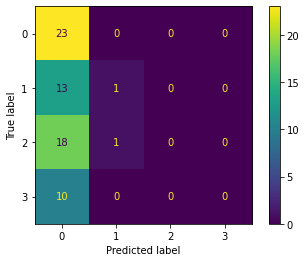

In [50]:
svc = SVC()
svc.fit(X_train2, y_train2)
y_pred2 = svc.predict(X_test2)

train_acc2 = round(svc.score(X_train2, y_train2) * 100, 1)
val_acc2 = round(accuracy_score(y_pred2, y_test2) * 100, 2)

print("Training Accuracy:",train_acc2 ,"%")
print("Model Accuracy Score :",val_acc2 ,"%")
plot_confusion_matrix(svc, X_test, y_test)